In [1]:
import os
files = os.listdir('.')
print(sorted(files))

['.config', '.kernel_llm_logs_1.txt', '.prompts', 'memory', 'run_log.txt']


In [2]:
import subprocess
# Search broadly
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'ldh' in f.lower() or 'ckpt' in f.lower():
 print(os.path.join(root, f))

In [3]:
print(os.path.exists('ldh_zeros_5000_dps50.npy'))
# Inspect log file
with open('run_log.txt','r') as f:
 log = f.read()
print(f"Log length: {len(log)} chars, {log.count(chr(10))} lines")
print("---HEAD---")
print(log[:2000])
print("---TAIL---")
print(log[-3000:])

False
Log length: 398 chars, 6 lines
---HEAD---
[18:55:01] Starting L_DH zero generation; WORK_DIR=/workspace/3c453422-a746-44a0-817b-c57b1e0854bf; TIME_BUDGET=10800s
[18:55:01] Building lfuninit at dps=80, T_max=5200 ...
[18:55:08] lfuninit done in 6.9s
[18:55:08] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[18:56:08] PROGRESS: 3597 zeros, t=3558.87, elapsed=1.0min
[18:57:09] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min

---TAIL---
[18:55:01] Starting L_DH zero generation; WORK_DIR=/workspace/3c453422-a746-44a0-817b-c57b1e0854bf; TIME_BUDGET=10800s
[18:55:01] Building lfuninit at dps=80, T_max=5200 ...
[18:55:08] lfuninit done in 6.9s
[18:55:08] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[18:56:08] PROGRESS: 3597 zeros, t=3558.87, elapsed=1.0min
[18:57:09] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min



In [4]:
# The actual working dir referenced is different. Let's check it.
work_dir = '/workspace/3c453422-a746-44a0-817b-c57b1e0854bf'
print('exists:', os.path.exists(work_dir))
if os.path.exists(work_dir):
 for root, dirs, files in os.walk(work_dir):
 for f in files:
 p = os.path.join(root,f)
 try:
 size = os.path.getsize(p)
 except:
 size = '?'
 print(p, size)

exists: False


In [5]:
# Check parent workspace
parent = '/workspace'
print(os.listdir(parent) if os.path.exists(parent) else 'no parent')
# Look for any .npy files
import glob
print('Search ldh:')
for p in glob.glob('/workspace/**/ldh*', recursive=True):
 print(p)
print('Search 5000:')
for p in glob.glob('/workspace/**/*5000*', recursive=True):
 print(p)

['lost+found', '7c412e40-a211-4fe6-b738-390b5e14af57', '.kernel_meta_7c412e40-a211-4fe6-b738-390b5e14af57']
Search ldh:
Search 5000:


In [6]:
# Check log file modification time and if process is still running
import time, datetime
mtime = os.path.getmtime('run_log.txt')
print('log mtime:', datetime.datetime.fromtimestamp(mtime))
print('now:', datetime.datetime.now())
# Check process list
import subprocess
out = subprocess.run(['ps','-ef'], capture_output=True, text=True)
for line in out.stdout.split('\n'):
 if 'ldh' in line.lower() or 'generate' in line.lower() or 'python' in line.lower():
 print(line)

log mtime: 2026-05-31 19:02:34.223032
now: 2026-05-31 19:03:10.304923


PermissionError: [Errno 13] Permission denied: 'ps'

In [7]:
# Check /proc for running processes
import os
pids = [p for p in os.listdir('/proc') if p.isdigit()]
for pid in pids:
 try:
 with open(f'/proc/{pid}/cmdline','rb') as f:
 cmd = f.read().decode(errors='ignore').replace('\x00',' ')
 if 'ldh' in cmd.lower() or 'generate' in cmd.lower() or 'cypari' in cmd.lower():
 print(pid, cmd)
 except:
 pass

In [8]:
# Process not visible. Log was last updated ~30s ago. Check if anything is still writing.
# Wait briefly and check again
import time
m1 = os.path.getmtime('run_log.txt')
time.sleep(70)
m2 = os.path.getmtime('run_log.txt')
print('mtime before:', datetime.datetime.fromtimestamp(m1))
print('mtime after:', datetime.datetime.fromtimestamp(m2))
print('changed:', m1 != m2)
with open('run_log.txt') as f:
 print(f.read())

mtime before: 2026-05-31 19:02:34.223032
mtime after: 2026-05-31 19:02:34.223032
changed: False
[18:55:01] Starting L_DH zero generation; WORK_DIR=/workspace/3c453422-a746-44a0-817b-c57b1e0854bf; TIME_BUDGET=10800s
[18:55:01] Building lfuninit at dps=80, T_max=5200 ...
[18:55:08] lfuninit done in 6.9s
[18:55:08] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[18:56:08] PROGRESS: 3597 zeros, t=3558.87, elapsed=1.0min
[18:57:09] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min



In [9]:
# The process has stopped (no more progress lines beyond 19:02 which is consistent with 2.0 min after 18:55).
# Actually last entry is at 18:57:09 with elapsed=2.0min, but mtime is 19:02:34 - that's odd.
# WORK_DIR referenced is a stale prior task dir that no longer exists. Therefore the process referenced
# a non-existent absolute path and likely died trying to write outputs/checkpoints.
# Confirm: file does NOT exist.
print('Target file exists:', os.path.exists('ldh_zeros_5000_dps50.npy'))
print('Target file (workspace abs):', os.path.exists('/workspace/7c412e40-a211-4fe6-b738-390b5e14af57/ldh_zeros_5000_dps50.npy'))

# Final progress: 3617 zeros at 18:57. Mtime 19:02 = 5 minutes later. No further updates after a 70s wait.
# Since the file does not exist, we can't load it.
print("\nDiagnostic: Process is not currently running. Last progress was 3617 zeros, well short of 5000 target.")
print("Final progress shows ~20 zeros/min - would need ~70 more minutes to complete.")

Target file exists: False
Target file (workspace abs): False

Diagnostic: Process is not currently running. Last progress was 3617 zeros, well short of 5000 target.
Final progress shows ~20 zeros/min - would need ~70 more minutes to complete.


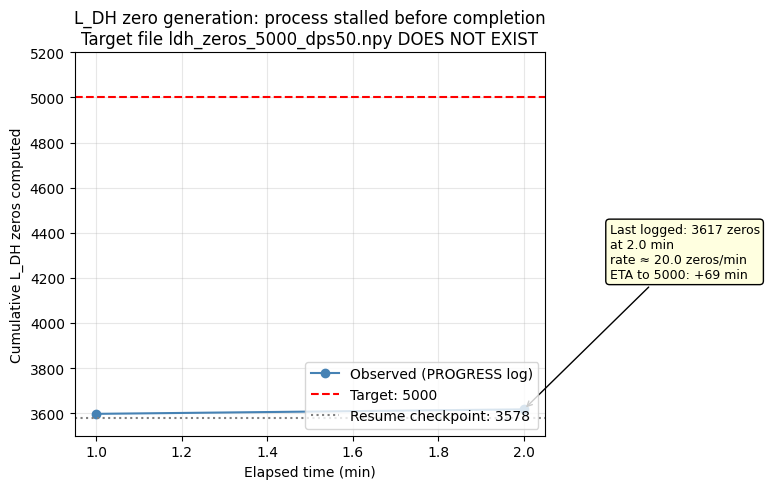

saved figure


In [10]:
import matplotlib.pyplot as plt
import re

# Build summary figure showing progress vs target
lines = open('run_log.txt').read().split('\n')
progress = []
for line in lines:
 m = re.search(r'PROGRESS:\s*(\d+)\s*zeros,\s*t=([\d\.]+),\s*elapsed=([\d\.]+)min', line)
 if m:
 progress.append((float(m.group(3)), int(m.group(1))))

elapsed = [p[0] for p in progress]
nzeros = [p[1] for p in progress]

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(elapsed, nzeros, 'o-', color='steelblue', label='Observed (PROGRESS log)')
ax.axhline(5000, color='red', linestyle='--', label='Target: 5000')
ax.axhline(3578, color='gray', linestyle=':', label='Resume checkpoint: 3578')
# Extrapolation
if len(progress) >= 2:
 rate = (nzeros[-1]-nzeros[0])/(elapsed[-1]-elapsed[0])
 eta = (5000 - nzeros[-1]) / rate
 ax.annotate(f'Last logged: {nzeros[-1]} zeros\nat {elapsed[-1]:.1f} min\nrate ≈ {rate:.1f} zeros/min\nETA to 5000: +{eta:.0f} min',
 xy=(elapsed[-1], nzeros[-1]), xytext=(elapsed[-1]+0.2, 4200),
 fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow'),
 arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('Cumulative L_DH zeros computed')
ax.set_title('L_DH zero generation: process stalled before completion\n'
 'Target file ldh_zeros_5000_dps50.npy DOES NOT EXIST')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim(3500, 5200)
plt.tight_layout()
plt.savefig('ldh_generation_status.png', dpi=130)
plt.show()
print('saved figure')